In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Параметры ВТОРОГО дня
test_day = 2
test_date = datetime(2026, 4, 21)
daily_traffic = 150

# Конверсии по группам
conversion_a = 0.05
conversion_b = 0.09

users = []
for i in range(1, daily_traffic + 1):
    user_id = 2000 + i
    
    group = 'A' if random.random() < 0.5 else 'B'
    
    if group == 'A':
        purchase_prob = conversion_a
    else:
        purchase_prob = conversion_b
    
    purchase_flag = 1 if random.random() < purchase_prob else 0
    
    if purchase_flag == 1:
        revenue = round(random.uniform(200, 1000), 2)
    else:
        revenue = 0
    
    if purchase_flag == 1:
        page_views = random.randint(5, 15)
    else:
        page_views = random.randint(1, 8)
    
    session_duration_sec = page_views * random.randint(15, 45)
    
    hour = random.randint(9, 21)
    minute = random.randint(0, 59)
    second = random.randint(0, 59)
    visited_at = test_date.replace(hour=hour, minute=minute, second=second)
    
    users.append({
        'user_id': user_id,
        'group_name': group,
        'visit_date': test_date.date(),
        'visited_at': visited_at,
        'purchase_flag': purchase_flag,
        'revenue': revenue,
        'page_views': page_views,
        'session_duration_sec': session_duration_sec
    })

df_day2 = pd.DataFrame(users)

print(" ДАННЫЕ ВТОРОГО ДНЯ ТЕСТА")
print("=" * 50)
print(f"Дата: {test_date.date()}")
print(f"Всего посетителей: {len(df_day2)}")
print(f"\nРаспределение по группам:")
print(df_day2['group_name'].value_counts())
print(f"\nКонверсия в день 2:")
for group in ['A', 'B']:
    group_data = df_day2[df_day2['group_name'] == group]
    conv = group_data['purchase_flag'].mean() * 100
    print(f"  Группа {group}: {len(group_data)} чел, конверсия {conv:.1f}%")

df_day2.to_csv('pen_shop_day2.csv', index=False)
print(f"\n✅ Файл 'pen_shop_day2.csv' сохранён")

📊 ДАННЫЕ ВТОРОГО ДНЯ ТЕСТА
Дата: 2026-04-21
Всего посетителей: 150

Распределение по группам:
group_name
B    76
A    74
Name: count, dtype: int64

Конверсия в день 2:
  Группа A: 74 чел, конверсия 5.4%
  Группа B: 76 чел, конверсия 3.9%

✅ Файл 'pen_shop_day2.csv' сохранён


Визуализация для 2 дня

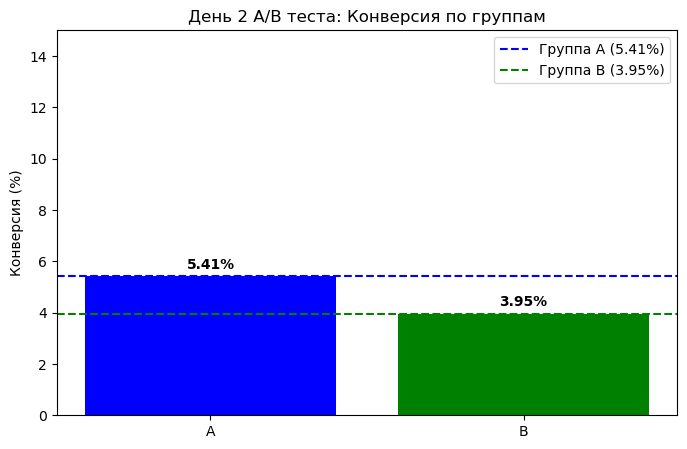


⚠️ ВАЖНО: Это только ДЕНЬ 2! Не делать выводов!
До завершения теста осталось дней: 7 дней


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Данные дня 2
data_day2 = pd.DataFrame({
    'group': ['A', 'B'],
    'visitors': [74, 76],
    'purchases': [4, 3],
    'conversion': [5.41, 3.95]  # 5.4% и 3.9%
})

# Построим график
plt.figure(figsize=(8, 5))
bars = plt.bar(data_day2['group'], data_day2['conversion'], color=['blue', 'green'])
plt.axhline(y=5.41, color='blue', linestyle='--', label='Группа A (5.41%)')
plt.axhline(y=3.95, color='green', linestyle='--', label='Группа B (3.95%)')
plt.ylabel('Конверсия (%)')
plt.title('День 2 A/B теста: Конверсия по группам')
plt.legend()
plt.ylim(0, 15)

# Добавим подписи на столбцах
for bar, conv in zip(bars, data_day2['conversion']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{conv}%', ha='center', fontweight='bold')

plt.show()

print("\n⚠️ ВАЖНО: Это только ДЕНЬ 2! Не делать выводов!")
print(f"До завершения теста осталось дней: {9 - 2} дней")

 Сравнительный график дня 1 и дня 2

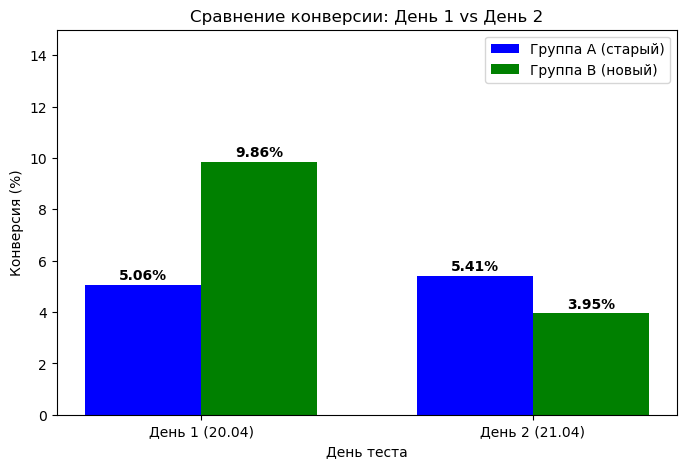


📊 ИТОГИ ДВУХ ДНЕЙ:
Группа A: день 1 = 5.06%, день 2 = 5.41%
Группа B: день 1 = 9.86%, день 2 = 3.95%

Группа B показала рост в день 1, но падение в день 2
⚠️ Это нормально для малой выборки!

До завершения теста осталось дней: 7 дней


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Данные за два дня
data_comparison = pd.DataFrame({
    'day': [1, 1, 2, 2],
    'group': ['A', 'B', 'A', 'B'],
    'conversion': [5.06, 9.86, 5.41, 3.95]
})

# Подготовка для группового графика
days = [1, 2]
x = np.arange(len(days))
width = 0.35

# Значения конверсии по группам
conv_A = [5.06, 5.41]
conv_B = [9.86, 3.95]

# Построим график
fig, ax = plt.subplots(figsize=(8, 5))
bars_A = ax.bar(x - width/2, conv_A, width, label='Группа A (старый)', color='blue')
bars_B = ax.bar(x + width/2, conv_B, width, label='Группа B (новый)', color='green')

# Настройки
ax.set_xlabel('День теста')
ax.set_ylabel('Конверсия (%)')
ax.set_title('Сравнение конверсии: День 1 vs День 2')
ax.set_xticks(x)
ax.set_xticklabels(['День 1 (20.04)', 'День 2 (21.04)'])
ax.set_ylim(0, 15)
ax.legend()

# Добавим подписи на столбцах
for bars in [bars_A, bars_B]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.2,
                f'{height}%', ha='center', fontweight='bold')

plt.show()

print("\n📊 ИТОГИ ДВУХ ДНЕЙ:")
print("=" * 40)
print(f"Группа A: день 1 = 5.06%, день 2 = 5.41%")
print(f"Группа B: день 1 = 9.86%, день 2 = 3.95%")
print(f"\nГруппа B показала рост в день 1, но падение в день 2")
print(" Это нормально для малой выборки!")
print(f"\nДо завершения теста осталось дней: {9 - 2} дней")

Накопленные результаты после двух дней